In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
import tensorflow as tf

In [ ]:
!nvidia-smi

Wed Dec 31 04:23:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#CONSTANTS

In [ ]:
# CONSTANTS
#N = 64
max_delay = 0
NUM_SC = 612
NUM_SLOTS = 14
ALPHA = 1/np.sqrt(10) # Normalization factor for QAM Mapping
NUM_DMRS_SYMBOLS = 816
# Using FR1 so setting subcarrier spacing to 15kHz
subcarrier_spacing = 15e3
center_frequency = 5e6
# Max delay = 3e-6
# So, symbol duration = 1/15e3 = 66.67e-6 seconds
# T_slot = 10^-3 / 2^u = 10^-3 / 2^0 = 1 ms
# CP duration, Tcp = (T_slot - 14*Tsym)/14 = 4.762 us > Max. Delay
# N - point FFT = 612
# Sampling period, Ts = 1/ f*N = 1/*15e3 *612) = 0.1089 us
# CP length = Tcp / Ts = 43.715
CP_LENGTH = 44
NUM_RESOURCE_GRID_SYMBOLS = NUM_SC * NUM_SLOTS
NUM_DATA_SYMBOLS = NUM_RESOURCE_GRID_SYMBOLS - NUM_DMRS_SYMBOLS
SYMBOL_LENGTH = NUM_SC + CP_LENGTH
SIGNAL_LEN =  SYMBOL_LENGTH * NUM_SLOTS
#snr_dB = 14
DMRS_CYCLE = np.array([(-1 + 1j), 3 + 1j, 1 - 1j, 1 + 3j]) *ALPHA
DMRS_INDICES = np.linspace(10, 8567, 816, dtype=int) # CHECK POINT 1!!!!!!!!!!
DMRS_POSITIONS = np.array([(i % NUM_SC,  i // NUM_SC) for i in DMRS_INDICES])
RESOURCE_GRID = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)

# sc_idx = subcarrier index, sym_idx = OFDM symbol index
for i, (sc_idx, sym_idx) in enumerate(DMRS_POSITIONS):
    RESOURCE_GRID[sc_idx, sym_idx] = DMRS_CYCLE[i % len(DMRS_CYCLE)]

DMRS_MASK = np.zeros((NUM_SC, NUM_SLOTS), dtype=bool)
for sc_idx, sym_idx in DMRS_POSITIONS:
    DMRS_MASK[sc_idx, sym_idx] = True

DATA_POSITIONS = []
for sym_idx in range(NUM_SLOTS):
  for sc_idx in range(NUM_SC):
    if not DMRS_MASK[sc_idx, sym_idx]:
      DATA_POSITIONS.append((sc_idx, sym_idx))
DATA_POSITIONS = np.array(DATA_POSITIONS)
PATH_DATAS = np.array([(0.04570882, 0),(1.0, 1.1457e-07),(0.60255959, 1.2075e-07),(0.39810717, 1.7604e-07),
(0.25118864, 1.383e-07), (0.15135612, 1.6125e-07), (0.1023293, 2.0124e-07), (0.08912509, 1.725e-07),
(0.17782794, 2.2854e-07),(0.02570396, 4.6125e-07),(0.21877616, 5.6934e-07),(0.02137962, 6.6726e-07),
(0.05754399, 6.5154e-07),(0.03019952, 7.4826e-07),(0.08317638, 7.5357e-07),(0.07413102, 9.1746e-07),
(0.05370318, 1.2243e-06),(0.02398833, 1.3373e-06),(0.01479108, 1.3709e-06),(0.0128825, 1.439e-06),
(0.02187762, 1.502e-06), (0.01023293, 1.5913e-06), (0.00107152, 2.8976e-06)])

NUM_TAPS = len(PATH_DATAS)

# Array of subcarrier frequencies - center frequency = 5 MHz, subcarrier spacing = 15 kHz
F = np.arange(-NUM_SC//2, NUM_SC//2) * subcarrier_spacing
FR = F + center_frequency

In [ ]:
gains = np.array([g for g, _ in PATH_DATAS])
gains /= np.sqrt(np.sum(gains**2))

PATH_DATAS_NORM = [(g, d) for g, (_, d) in zip(gains, PATH_DATAS)]
gains = np.array([g for g, _ in PATH_DATAS_NORM])
pdp_energy = np.sum(gains**2)

print("PDP energy =", pdp_energy)

PDP energy = 1.0000000000000002


#OFDM TRANSMITTER

In [ ]:
# Generate Data and modulate

qam_map = {
    (0,0,0,0): ALPHA* (1 + 1j),
    (0,0,0,1): ALPHA* (1 + 3j),
    (0,0,1,1): ALPHA* (1 - 3j),
    (0,0,1,0): ALPHA* (1 - 1j),

    (0,1,0,0): ALPHA* (3 + 1j),
    (0,1,0,1): ALPHA* (3 + 3j),
    (0,1,1,1): ALPHA* (3 - 3j),
    (0,1,1,0): ALPHA* (3 - 1j),

    (1,1,0,0): ALPHA*(-3 + 1j),
    (1,1,0,1): ALPHA*(-3 + 3j),
    (1,1,1,1): ALPHA*(-3 - 3j),
    (1,1,1,0): ALPHA*(-3 - 1j),

    (1,0,0,0): ALPHA*(-1 + 1j),
    (1,0,0,1): ALPHA*(-1 + 3j),
    (1,0,1,1): ALPHA*(-1 - 3j),
    (1,0,1,0): ALPHA*(-1 - 1j),
}

qam_demap = {v: k for k, v in qam_map.items()} # CHECK POINT 2!!!!!!!!

def qam_mapping(bit_stream):
  L = len(bit_stream)
  bit_grps = [tuple(bit_stream[i:i+4]) for i in range(0, L, 4)]
  qam_symbols = np.array([qam_map[grp] for grp in bit_grps])
  return qam_symbols

In [ ]:
def random_bits(length):
  return np.random.randint(0,2,length)

# currently this will only ever return a 612 x 14 resource grid
def bit_stream_to_resource_grid(bit_stream):
  data_symbols = qam_mapping(bit_stream)
  resource_grid = np.copy(RESOURCE_GRID)

  count = 0  # for verification
  for n, (sc_idx, sym_idx) in enumerate(DATA_POSITIONS):
    count += 1
    resource_grid[sc_idx, sym_idx] = data_symbols[n]
  return data_symbols,resource_grid

def time_domain_symbols(resource_grid): #change the list name in OFDM Transmitter
  time_domain_symbols = []
  for sym_idx in range(NUM_SLOTS):
      frequency_domain_symbol = resource_grid[:, sym_idx]  # 612 subcarriers
      time_domain_symbol = np.fft.ifft(frequency_domain_symbol, 612)
      time_domain_symbols.append(time_domain_symbol)
  return time_domain_symbols

def apply_cyclic_prefix(time_domain_symbols):
  symbols_with_cp = []
  for time_symbol in time_domain_symbols:
      symbol_with_cp = np.concatenate([time_symbol[-CP_LENGTH:], time_symbol])
      symbols_with_cp.append(symbol_with_cp)
  return np.concatenate(symbols_with_cp)

# Transmitted Signal

In [ ]:
bit_stream = random_bits(7752*4)
data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
transmitted_signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))

Pilots placed: 816
Data symbols used: 7752
Empty resource elements: 0


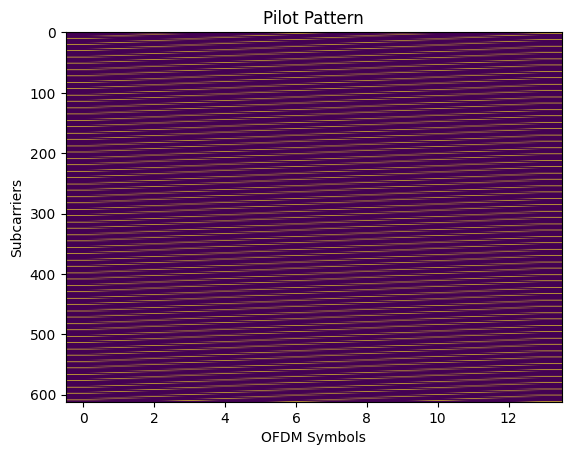

In [ ]:
# Resource Grid verification
n = len(data_symbols)
print(f"Pilots placed: {np.sum(DMRS_MASK)}")  # Should be 816
print(f"Data symbols used: {n}")  # Should be 7752
empty_res = np.sum(resource_grid == 0)
print(f"Empty resource elements: {empty_res}")  # Should be 0
plt.imshow(DMRS_MASK, aspect='auto')  # .T for proper time/freq orientation
plt.ylabel('Subcarriers')
plt.xlabel('OFDM Symbols')
plt.title('Pilot Pattern')

np.save('resource_grid.npy', resource_grid)

if not (resource_grid == np.load('resource_grid.npy')).all():
  raise ValueError("Resource Grid not matching")

#MULTIPATH CHANNEL

In [ ]:
def apply_multipath(path_datas, t_signal):
    Fs = NUM_SC * subcarrier_spacing
    delays_samples = [int(round(delay * Fs)) for _, delay in path_datas]
    h = np.zeros(max(delays_samples) + 1, dtype=complex)
    nlos_gains = np.array([p[0] for p in path_datas])
    for i, n in enumerate(delays_samples):
        h[n] += (nlos_gains[i] / np.sqrt(2)) * (np.random.randn() + 1j*np.random.randn())
    r_signal = np.convolve(t_signal, h, mode='full')[:len(t_signal)]
    H = np.fft.fft(h, NUM_SC)
    return r_signal, H

In [ ]:
# def apply_multipath(path_datas, t_signal):
#     Fs = NUM_SC * subcarrier_spacing
#     delays_samples = [int(round(delay * Fs)) for _, delay in path_datas]
#     max_delay = max(delays_samples)
#     h = np.zeros(max_delay + 1, dtype=complex)
#     for (loss, delay), n in zip(path_datas, delays_samples):
#         h[n] += loss
#     r_signal = np.convolve(t_signal, h, mode='full')[:len(t_signal)]
#     H = np.fft.fft(h, NUM_SC)
#     return r_signal, H
# Wrong, use the sum of impulses in the time domain, as above.
#def channel_impulse_response(path_datas, f):
#    """
#    Build channel impulse response from multipath model.
#    path_datas: list of (loss, delay) in seconds
#    f: subcarrier frequencies (Hz), shape (NUM_SC,)
#    num_taps: length of impulse response
#    """
#    H = np.zeros(len(f), dtype=complex)
#    for loss, delay in path_datas:
#        H += loss * np.exp(-1j * 2 * np.pi * f * delay)
#    return H

#def apply_multipath(path_datas, t_signal, FR):
#  r_signal = np.zeros(SIGNAL_LEN, dtype = complex)
#  H = channel_impulse_response(path_datas, FR)
#  h = np.fft.ifft(np.fft.ifftshift(H), NUM_SC)   # impulse response
#  r_signal = np.convolve(t_signal, h, mode='full')[:len(t_signal)]
#  return r_signal,H

# assert all(received_signal_multipath == transmitted_signal)

# CHANNEL ESTIMATION

In [ ]:
'''
def lin_interpolate(data: array[(x, y)], val):
  for (a1, a2) in data.windows(2):
    x1, y1, x2, y2 = a1, a2
    if x1 < vl < x2:
      # linear interplation on x1,x2,y1,y2
'''
# -- RECEIVER --
def preprocessing(r_signal):
  received_symbols = []

  for i in range(NUM_SLOTS):
      start_idx = i * SYMBOL_LENGTH
      end_idx = start_idx + SYMBOL_LENGTH

      if end_idx <= len(r_signal):
          symbol_with_cp = r_signal[start_idx:end_idx]
          symbol_no_cp = symbol_with_cp[CP_LENGTH:]
          freq_domain_symbol = np.fft.fft(symbol_no_cp, NUM_SC)
          received_symbols.append(freq_domain_symbol)
  return np.array(received_symbols)

# Applying method of least squares and performing linear interpolation
def LS_strategy(r_signal, *params):
  received_pilots = [(i,value) for i, value in enumerate(r_signal) if i in DMRS_INDICES]
  #print("No. of received pilots:", len(received_pilots))
  channel_response = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
  for (idx, val) in received_pilots:
    channel_response[idx % NUM_SC, idx // NUM_SC] = val / RESOURCE_GRID[idx % NUM_SC, idx // NUM_SC]
  return channel_response

def lin_interpolation(x_points, y_points, X):
  results = []
  for x in X:
    if x < x_points[0]:
      results.append (y_points[0])
    elif x > x_points[-1]:
      results.append(y_points[-1])
    else:
      for i in range (len(x_points)-1):
        x1, x2 = x_points[i], x_points[i+1]
        y1, y2 = y_points[i], y_points[i+1]
        if x1 <= x <= x2:
          t = (x - x1) / (x2 - x1)
          results.append(y1 + t * (y2 - y1))
          break
  return np.array(results, dtype = complex)

def channel_interpolation(dmrs_estimate_grid):
  H_est = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
  # Interpolation across frequency
  for sym in range(NUM_SLOTS):
    pilot_sc = DMRS_POSITIONS[DMRS_POSITIONS[:,1] == sym, 0]
    pilot_vals = dmrs_estimate_grid[pilot_sc, sym]
    if len(pilot_sc) == 0:
      continue  # no pilots in this symbol
    H_est[:, sym] = lin_interpolation(pilot_sc, pilot_vals, np.arange(NUM_SC))
  return H_est

In [ ]:
# --- LMMSE Estimator ---
'''
1. LS Estimates H_LS (612 * 14 grid, with 816 estimated values and remaining zeroes)
2. Noise variance estimation
3. Computation of Channel and Noise Covariances
4. LMMSE application
'''

def compute_R_HH():
  tap_powers = PATH_DATAS[:,0]
  tap_delays = PATH_DATAS[:,1]
  R_HH = np.zeros((NUM_SC, NUM_SC), dtype=complex)
  ks = np.arange (NUM_SC)
  for k in range(NUM_SC):
    for m in range(NUM_SC):
      d = k - m
      R_HH[k, m] = np.sum(tap_powers * np.exp(-1j *2*np.pi*d*subcarrier_spacing*tap_delays))
  return R_HH

def compute_R_HY(R_HH_allp, X_p):
    return R_HH_allp @ np.conjugate(X_p.T)

def compute_R_YY(noise_var, X_p, R_HH_pp):
  R_YY = X_p @ R_HH_pp @ np.conjugate(X_p.T) + noise_var* np.eye(816)
  return R_YY

def LMMSE(R_HY, R_YY, r_signal):
  r_dmrs = r_signal[DMRS_INDICES].reshape(-1, 1)
  return R_HY @ np.linalg.inv(R_YY) @ r_dmrs

# OFDM RECEIVER

# HELPER FUNCTIONS

In [ ]:
# AWGN Channel
def add_AWGN(signal, snr_dB):
  signal_power = np.mean(np.abs(signal)**2)
  snr = 10 ** (snr_dB/10)
  noise_power = signal_power/snr
  noise_real = np.random.normal(0, np.sqrt(noise_power/2), len(signal))
  noise_imag = np.random.normal(0, np.sqrt(noise_power/2), len(signal))
  noise = noise_real + 1j * noise_imag
  received_signal = signal + noise

  return received_signal, noise

In [ ]:
def square_distance(cmplx1, cmplx2):
  return (cmplx1.real - cmplx2.real)**2 + (cmplx1.imag - cmplx2.imag)**2

# turns complex number into bit pattern corrsesponding to closest QAM symbol
def ML_Decoder(qam_symbol):
  qam_symbols = list(qam_demap.keys())
  min_index = np.argmin([square_distance(qam_symbol, sym) for sym in qam_symbols])
  closest_symbol = qam_symbols[min_index]
  return qam_demap[closest_symbol]

# Adds pad_length elements from end of qam_symbols to beginnging
def cyclic_prefix(qam_symbols, pad_length):
  return qam_symbols[-pad_length:] + qam_symbols

# Maps list of complex numbers to a list of bits
def qam_demapping(qam_symbols):
  decoded_bits = []
  for symbol in qam_symbols:
    bits = ML_Decoder(symbol)
    decoded_bits.extend(bits)
  return np.array(decoded_bits)

def calculate_mse(original_symbols, received_symbols):
    """Calculate Mean Square Error between symbol constellations"""
    if len(original_symbols) != len(received_symbols):
        min_len = min(len(original_symbols), len(received_symbols))
        original_symbols = original_symbols[:min_len]
        received_symbols = received_symbols[:min_len]

    mse = np.mean(np.abs(np.array(original_symbols) - np.array(received_symbols))**2)
    return mse
def calculate_ber(original_bits, decoded_bits):
    """Calculate Bit Error Rate"""
    if len(original_bits) != len(decoded_bits):
        min_len = min(len(original_bits), len(decoded_bits))
        original_bits = original_bits[:min_len]
        decoded_bits = decoded_bits[:min_len]

    errors = np.sum(original_bits != decoded_bits)
    ber = errors / len(original_bits)
    return ber, errors

In [ ]:
def signal_to_grid(signal):
  received_symbols = []

  for i in range(NUM_SLOTS):
      start_idx = i * SYMBOL_LENGTH
      end_idx = start_idx + SYMBOL_LENGTH

      if end_idx <= len(signal):
          symbol_with_cp = signal[start_idx:end_idx]
          symbol_no_cp = symbol_with_cp[CP_LENGTH:]
          freq_domain_symbol = np.fft.fft(symbol_no_cp, NUM_SC)
          received_symbols.append(freq_domain_symbol)

  received_grid = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
  for sym_idx, freq_symbol in enumerate(received_symbols):
      received_grid[:, sym_idx] = freq_symbol
  return received_grid

def grid_to_data_symbols(grid):
  received_data_symbols = []
  for sc_idx, sym_idx in DATA_POSITIONS:
      received_data_symbols.append(grid[sc_idx, sym_idx])
  # print(f"Extracted {len(received_data_symbols)} received data symbols")
  return received_data_symbols

# EQUALIZATION

In [ ]:
# ZF equalizer and MMSE Equalizer
def zf_equalizer(r_signal, channel_response, epsilon=1e-10):
  return r_signal / np.where(np.abs(channel_response) > epsilon, channel_response, epsilon)

def mmse_equalizer(r_signal, channel_response, noise_var, symbol_power=1.0):
    """
    r_signal: received symbols in frequency domain (after FFT)
    channel_response: estimated channel response H[k]
    noise_var: estimated noise variance (sigma_n^2)
    symbol_power: average transmitted symbol power (sigma_x^2, usually 1 for normalized constellations)
    """
    H_conj = np.conj(channel_response)
    denom = np.abs(channel_response)**2 + noise_var/symbol_power
    return (H_conj / denom) * r_signal

In [ ]:
r_signal, H_true = apply_multipath(PATH_DATAS_NORM, transmitted_signal)
#scale = np.sqrt(np.mean(np.abs(H_true)**2))
#r_signal_norm = r_signal / scale
#H_true_norm = H_true / scale
print("Tx signal power:", np.mean(np.abs(transmitted_signal)**2))
print("Rx (no noise) power:", np.mean(np.abs(r_signal)**2))
received_signal, noise = add_AWGN(r_signal, 25)
received_symbols = preprocessing(received_signal)
ls_dmrs_estimate = LS_strategy(np.concatenate(received_symbols))
interpolated_channel_response = channel_interpolation(ls_dmrs_estimate)
true_H_grid = np.tile(H_true[:, None], (1, NUM_SLOTS))
print("Measured SNR:",
      10*np.log10(
          np.mean(np.abs(r_signal)**2) /
          np.mean(np.abs(received_signal - r_signal)**2)
      ))
print("LS pilot MSE:",
      np.mean(np.abs(ls_dmrs_estimate[DMRS_MASK] -
                     true_H_grid[DMRS_MASK])**2))
print("Mean |H|^2:", np.mean(np.abs(H_true)**2))

Tx signal power: 0.0015649513019947074
Rx (no noise) power: 0.00422345976357134
Measured SNR: 24.96652981895442
LS pilot MSE: 0.023809313777702384
Mean |H|^2: 2.710995812429102


In [ ]:
received_signal_multipath, H = apply_multipath(PATH_DATAS_NORM, transmitted_signal)
print("\n===== CHANNEL POWER CHECK =====")
print("Mean |H|^2 before scaling:", np.mean(np.abs(H)**2))
#print(h)
scale = np.sqrt(np.mean(np.abs(H)**2))
received_signal_norm = received_signal_multipath / scale
H_true_norm = H / scale
print("Scale factor:", scale)
print("Mean |H_true_norm|^2:", np.mean(np.abs(H_true_norm)**2))
print("\n===== RX POWER CHECK =====")
print("Mean |received_signal_norm|^2:",
      np.mean(np.abs(received_signal_norm)**2))
received_signal_awgn, noise_power = add_AWGN(received_signal_norm, 22)
print("Noise variance used:", noise_power)
print("Mean |received_signal_awgn|^2:",
      np.mean(np.abs(received_signal_awgn)**2))
pre_processed_ofdm_symbols = preprocessing(received_signal_awgn)
flattened_preprocessed_symbols = np.concatenate(pre_processed_ofdm_symbols)
LS_DMRS_Estimate = LS_strategy(flattened_preprocessed_symbols)
print("\n===== LS PILOT CHECK =====")

pilot_ls_vals = []
pilot_true_vals = []

for (sc_idx, sym_idx) in DMRS_POSITIONS:
    pilot_ls_vals.append(LS_DMRS_Estimate[sc_idx, sym_idx])
    pilot_true_vals.append(H_true_norm[sc_idx])

pilot_ls_vals = np.array(pilot_ls_vals)
pilot_true_vals = np.array(pilot_true_vals)

print("Mean |H_true_norm|^2 (pilots):",
      np.mean(np.abs(pilot_true_vals)**2))

print("Mean |H_LS_pilot|^2:",
      np.mean(np.abs(pilot_ls_vals)**2))

print("Ratio LS/True power:",
      np.mean(np.abs(pilot_ls_vals)**2) /
      np.mean(np.abs(pilot_true_vals)**2))
interpolated_channel_response = channel_interpolation(LS_DMRS_Estimate)
print("\n===== INTERPOLATION CHECK =====")

print("Mean |H_interp|^2:",
      np.mean(np.abs(interpolated_channel_response)**2))

print("Mean |H_true_norm|^2:",
      np.mean(np.abs(H_true_norm)**2))

print("Ratio interp/true:",
      np.mean(np.abs(interpolated_channel_response)**2) /
      np.mean(np.abs(H_true_norm)**2))


# Verify interpolation
print("\nExample:")
sc_idx, sym_idx = DMRS_POSITIONS[0]
print(f"Original pilot value at ({sc_idx}, {sym_idx}):", LS_DMRS_Estimate[sc_idx, sym_idx])
print(f"Interpolated value at same point: {interpolated_channel_response[sc_idx, sym_idx]}")

# Example of an interpolated (non-pilot) point
non_pilot_sc, non_pilot_sym = (100, 5)
print(f"\nInterpolated non-pilot value at ({non_pilot_sc}, {non_pilot_sym}): {interpolated_channel_response[non_pilot_sc, non_pilot_sym]:.2f}")
symbol_to_plot = 7  # Choose an arbitrary symbol index (e.g., the middle one)
channel_slice = interpolated_channel_response[:, symbol_to_plot]

channel_magnitude = np.abs(channel_slice)
print("Magnitudes:", channel_magnitude[:11])
channel_phase = np.angle(channel_slice)
noise_var = np.mean(np.abs(noise_power)**2)
rx_symbols = np.array(pre_processed_ofdm_symbols).T
rx_symbols_zf = zf_equalizer(rx_symbols, interpolated_channel_response)
rx_symbols_mmse = mmse_equalizer(rx_symbols, interpolated_channel_response, NUM_SC*noise_var)
equalized_zf_grid = np.array(rx_symbols_zf)   # (NUM_SLOTS, NUM_SC)
equalized_mmse_grid = np.array(rx_symbols_mmse)
rx_data_zf = []
rx_data_mmse = []
for sc_idx, sym_idx in DATA_POSITIONS:
    rx_data_zf.append(equalized_zf_grid[sc_idx, sym_idx])
    rx_data_mmse.append(equalized_mmse_grid[sc_idx, sym_idx])

rx_data_zf = np.array(rx_data_zf, dtype=complex)
rx_data_mmse = np.array(rx_data_mmse, dtype=complex)

# Now demap data-only symbols
decoded_bits_zf = qam_demapping(rx_data_zf)      # returns 1D array of bits
decoded_bits_mmse = qam_demapping(rx_data_mmse)
ber_zf, errors_zf = calculate_ber(bit_stream, decoded_bits_zf)
ber_mmse, errors_mmse = calculate_ber(bit_stream, decoded_bits_mmse)

mse_zf = calculate_mse(data_symbols, rx_data_zf)
mse_mmse = calculate_mse(data_symbols, rx_data_mmse)

print(f"SNR = 22 dB")
print(f"ZF  -> BER = {ber_zf}, MSE = {mse_zf}")
print(f"MMSE -> BER = {ber_mmse}, MSE = {mse_mmse}")


===== CHANNEL POWER CHECK =====
Mean |H|^2 before scaling: 2.710995812429102
Scale factor: 1.6465101920210217
Mean |H_true_norm|^2: 1.0000000000000004

===== RX POWER CHECK =====
Mean |received_signal_norm|^2: 0.0015607164058152238
Noise variance used: [-0.00088786+0.00082j    -0.00502271-0.00076711j -0.0022865 -0.00010469j
 ... -0.0016932 +0.00235j    -0.00238396+0.00298662j
  0.00251701+0.00143524j]
Mean |received_signal_awgn|^2: 0.0015674412827313224

===== LS PILOT CHECK =====
Mean |H_true_norm|^2 (pilots): 0.9999595237517023
Mean |H_LS_pilot|^2: 1.0170050296089186
Ratio LS/True power: 1.017046195823271

===== INTERPOLATION CHECK =====
Mean |H_interp|^2: 1.0080656169999376
Mean |H_true_norm|^2: 1.0000000000000004
Ratio interp/true: 1.0080656169999371

Example:
Original pilot value at (10, 0): (1.7984976341427374-0.2939387012991545j)
Interpolated value at same point: (1.7984976341427374-0.2939387012991545j)

Interpolated non-pilot value at (100, 5): 0.50-1.07j
Magnitudes: [1.641254

In [ ]:

R_HH = compute_R_HH()
np.allclose(R_HH, R_HH.conj().T) # bcoz R_HH is a hermitian matrix!
pilot_sc = DMRS_POSITIONS[:,0]
pilot_sym = DMRS_POSITIONS[:,1]
pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
X_p = np.diag(pilot_symbols)
R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
R_HH_allp = R_HH[:, pilot_sc]
R_HY = compute_R_HY(R_HH_allp, X_p)
R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
lmmse = LMMSE(R_HY, R_YY, flattened_preprocessed_symbols)

# PLOT SCRIPTS

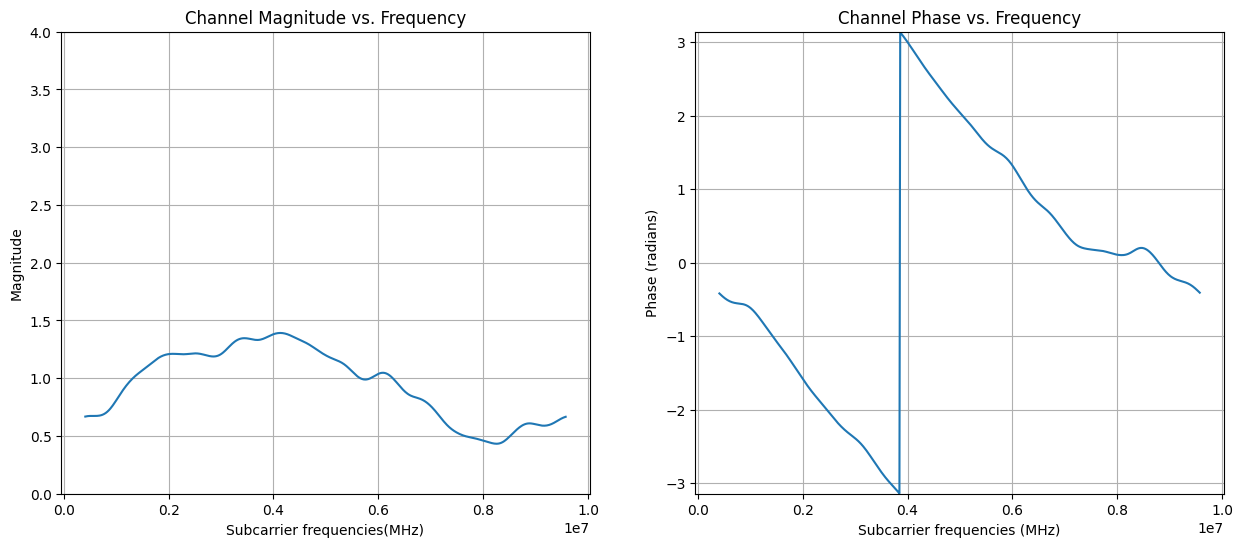

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
subcarrier_indices = np.arange(NUM_SC)
# Plot Magnitude
ax1.plot(FR, np.abs(H_true_norm))
ax1.set_title(f'Channel Magnitude vs. Frequency')
ax1.set_xlabel('Subcarrier frequencies(MHz)')
ax1.set_ylabel('Magnitude')
ax1.set_ylim(0,4)
ax1.ticklabel_format(useOffset=False)
ax1.grid(True)

# Plot Phase
ax2.plot(FR, np.angle(H_true_norm))
ax2.set_title(f'Channel Phase vs. Frequency')
ax2.set_xlabel('Subcarrier frequencies (MHz)')
ax2.set_ylabel('Phase (radians)')
ax2.set_ylim(-np.pi, np.pi)
ax2.grid(True)

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# subcarrier_indices = np.arange(NUM_SC)
# # Plot Magnitude
# ax1.plot(FR, channel_magnitude)
# ax1.set_title(f'Channel Magnitude vs. Frequency (Symbol {symbol_to_plot})')
# ax1.set_xlabel('Subcarrier frequencies(MHz)')
# ax1.set_ylabel('Magnitude')
# ax1.set_ylim(0,4)
# ax1.ticklabel_format(useOffset=False)
# ax1.grid(True)

# # Plot Phase
# ax2.plot(FR, channel_phase)
# ax2.set_title(f'Channel Phase vs. Frequency (Symbol {symbol_to_plot})')
# ax2.set_xlabel('Subcarrier frequencies (MHz)')
# ax2.set_ylabel('Phase (radians)')
# ax2.set_ylim(-np.pi, np.pi)
# ax2.grid(True)

In [ ]:
# snr_dB = 24
# received_signal, noise = add_AWGN(transmitted_signal, snr_dB)
# # CHANNEL - AWGN
# print("\n=== CHANNEL ===")
# print(f"Added AWGN with SNR = {snr_dB} dB")

# print("\n=== RECEIVER ===")
# # Receiver
# symbol_length = NUM_SC + CP_LENGTH
# received_symbols = []

# for i in range(NUM_SLOTS):
#     start_idx = i * symbol_length
#     end_idx = start_idx + symbol_length

#     if end_idx <= len(received_signal):
#         symbol_with_cp = received_signal[start_idx:end_idx]
#         symbol_no_cp = symbol_with_cp[CP_LENGTH:]
#         freq_domain_symbol = np.fft.fft(symbol_no_cp, NUM_SC)
#         received_symbols.append(freq_domain_symbol)

# # Reconstruct resource grid
# received_RESOURCE_GRID = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
# for sym_idx, freq_symbol in enumerate(received_symbols):
#     received_RESOURCE_GRID[:, sym_idx] = freq_symbol

# received_data_symbols = []
# for sc_idx, sym_idx in DATA_POSITIONS:
#     received_data_symbols.append(received_RESOURCE_GRID[sc_idx, sym_idx])

# print(f"Extracted {len(received_data_symbols)} received data symbols")

# # Demodulate QAM symbols
# decoded_bits = qam_demapping(received_data_symbols)
# print(f"Decoded {len(decoded_bits)} bits")
# # BER vs SNR Analysis
# print("\n=== BER vs SNR Analysis ===")
# snr_range = np.arange(-4,25,2)
# ber_results = []
# mse_results = []
# for snr in snr_range:
#     # Add noise
#     noisy_signal, _ = add_AWGN(transmitted_signal, snr)

#     # Receiver processing
#     rx_symbols = []
#     for i in range(NUM_SLOTS):
#         start_idx = i * symbol_length
#         end_idx = start_idx + symbol_length

#         if end_idx <= len(noisy_signal):
#             symbol_with_cp = noisy_signal[start_idx:end_idx]
#             symbol_no_cp = symbol_with_cp[CP_LENGTH:]
#             freq_domain_symbol = np.fft.fft(symbol_no_cp, NUM_SC)
#             rx_symbols.append(freq_domain_symbol)

#     # Reconstruct and extract data
#     rx_RESOURCE_GRID = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
#     for sym_idx, freq_symbol in enumerate(rx_symbols):
#         rx_RESOURCE_GRID[:, sym_idx] = freq_symbol

#     rx_data_symbols = [rx_RESOURCE_GRID[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]
#     rx_bits = qam_demapping(rx_data_symbols)

#     ber_val, _ = calculate_ber(bit_stream, rx_bits)
#     ber_results.append(ber_val)
#     mse_val = calculate_mse(data_symbols, rx_data_symbols)
#     mse_results.append(mse_val)
#     print(f"SNR: {snr:2d} dB, BER: {ber_val:.6f}, MSE: {mse_val:.6f}")

# # Plot BER vs SNR
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ax1.semilogy(snr_range, ber_results, 'o-')
# ax1.set_xlabel('SNR (dB)')
# ax1.set_ylabel('Bit Error Rate (BER)')
# ax1.set_title('BER vs SNR for OFDM with 16-QAM over AWGN Channel')
# ax1.grid(True, which='both')

# ax2.plot(snr_range, mse_results, 'o-')
# ax2.set_xlabel('SNR (dB)')
# ax2.set_ylabel('Mean Square Error (MSE)')
# ax2.set_title('MSE vs SNR for OFDM with 16-QAM over AWGN Channel')
# ax2.grid(True, which='both')


# print(f"\nSimulation completed successfully!")
# print(f"Resource grid shape: {RESOURCE_GRID.shape}")
# print(f"Total resource elements: {NUM_SC * NUM_SLOTS}")
# print(f"Pilot overhead: {np.sum(DMRS_MASK) / (NUM_SC * NUM_SLOTS) * 100:.1f}%")

In [ ]:
# print("rx_symbols_zf shape:", rx_symbols_zf.shape)
# snr_range = np.arange(-4,31,2)
# ber_zf_list = []
# ber_mmse_list = []
# mse_zf_list = []
# mse_mmse_list = []
# for snr_dB in snr_range:
#     # --- Transmit through channel ---
#     received_signal_multipath,h = apply_multipath(PATH_DATAS, transmitted_signal,f)
#     received_signal_awgn, noise_multipath = add_AWGN(received_signal_multipath, snr_dB)

#     # --- Receiver preprocessing ---
#     pre_processed_ofdm_symbols = preprocessing(received_signal_awgn)
#     flattened_preprocessed_symbols = np.concatenate(pre_processed_ofdm_symbols)
#     LS_DMRS_Estimate = LS_strategy(flattened_preprocessed_symbols)
#     interpolated_channel_response = channel_interpolation(LS_DMRS_Estimate)

#     # --- Equalization ---
#     noise_var = np.mean(np.abs(noise_multipath)**2)
#     rx_symbols = np.array(pre_processed_ofdm_symbols).T  # shape (SC, symbols)

#     rx_symbols_zf = zf_equalizer(rx_symbols, interpolated_channel_response)
#     rx_symbols_mmse = mmse_equalizer(rx_symbols, interpolated_channel_response, noise_var)

#     equalized_zf_grid = np.array(rx_symbols_zf)
#     equalized_mmse_grid = np.array(rx_symbols_mmse)

#     # --- Extract only data subcarriers ---
#     rx_data_zf = [equalized_zf_grid[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]
#     rx_data_mmse = [equalized_mmse_grid[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]

#     rx_data_zf = np.array(rx_data_zf, dtype=complex)
#     rx_data_mmse = np.array(rx_data_mmse, dtype=complex)

#     # --- Demap to bits ---
#     decoded_bits_zf = qam_demapping(rx_data_zf)
#     decoded_bits_mmse = qam_demapping(rx_data_mmse)

#     # --- BER calculation ---
#     ber_zf, _ = calculate_ber(bit_stream, decoded_bits_zf)
#     ber_mmse, _ = calculate_ber(bit_stream, decoded_bits_mmse)

#     ber_zf_list.append(ber_zf)
#     ber_mmse_list.append(ber_mmse)

#     # --- MSE calculation ---
#     mse_zf = calculate_mse(data_symbols, rx_data_zf)
#     mse_mmse = calculate_mse(data_symbols, rx_data_mmse)

#     mse_zf_list.append(mse_zf)
#     mse_mmse_list.append(mse_mmse)

#     print(f"SNR = {snr_dB} dB -> ZF BER = {ber_zf:.4f}, ZF MSE = {mse_zf:.4f}, MMSE BER = {ber_mmse:.4f}, MMSE MSE = {mse_mmse:.4f}")

# # --- Plot results ---

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ax1.semilogy(snr_range, ber_zf_list, 'o-', label = "ZF Equalizer")
# ax1.semilogy(snr_range, ber_mmse_list, 's-', label = "MMSE Equalizer")
# ax1.set_xlabel('SNR (dB)')
# ax1.set_ylabel('Bit Error Rate (BER)')
# ax1.set_title('BER vs. SNR (ZF vs MMSE)')
# ax1.grid(True, which='both')
# ax1.legend()

# ax2.plot(snr_range, mse_zf_list, 'o-', label='ZF Equalizer')
# ax2.plot(snr_range, mse_mmse_list, 's-', label='MMSE Equalizer')
# ax2.set_xlabel('SNR (dB)')
# ax2.set_ylabel('Mean Square Error (MSE)')
# ax2.set_title('MSE vs. SNR (ZF vs. MMSE)')
# ax2.grid(True, which='both')
# ax2.legend()

In [ ]:
# num_iterations = 100   # Monte Carlo runs
# snr_range = np.arange(-4, 31, 2)

# #ber_zf_list = []
# #ber_mmse_list = []
# mse_zf_list = []
# mse_mmse_list = []

# for snr_dB in snr_range:
#     #ber_zf_accum = 0.0
#     #ber_mmse_accum = 0.0
#     mse_zf_accum = 0.0
#     mse_mmse_accum = 0.0

#     for _ in range(num_iterations):
#         # --- Transmit through channel ---
#         received_signal_multipath,_ = apply_multipath(PATH_DATAS, transmitted_signal,f)
#         received_signal_awgn, noise_multipath = add_AWGN(received_signal_multipath, snr_dB)

#         # --- Receiver preprocessing ---
#         pre_processed_ofdm_symbols = preprocessing(received_signal_awgn)
#         flattened_preprocessed_symbols = np.concatenate(pre_processed_ofdm_symbols)
#         LS_DMRS_Estimate = LS_strategy(flattened_preprocessed_symbols)
#         interpolated_channel_response = channel_interpolation(LS_DMRS_Estimate)

#         # --- Equalization ---
#         noise_var = np.mean(np.abs(noise_multipath)**2)
#         rx_symbols = np.array(pre_processed_ofdm_symbols).T  # shape (SC, symbols)

#         rx_symbols_zf = zf_equalizer(rx_symbols, interpolated_channel_response)
#         rx_symbols_mmse = mmse_equalizer(rx_symbols, interpolated_channel_response, noise_var)

#         equalized_zf_grid = np.array(rx_symbols_zf)
#         equalized_mmse_grid = np.array(rx_symbols_mmse)

#         # --- Extract only data subcarriers ---
#         rx_data_zf = [equalized_zf_grid[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]
#         rx_data_mmse = [equalized_mmse_grid[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]

#         rx_data_zf = np.array(rx_data_zf, dtype=complex)
#         rx_data_mmse = np.array(rx_data_mmse, dtype=complex)

#         # --- Demap to bits ---
#         #decoded_bits_zf = qam_demapping(rx_data_zf)
#         #decoded_bits_mmse = qam_demapping(rx_data_mmse)

#         # --- BER calculation ---
#         #ber_zf, _ = calculate_ber(bit_stream, decoded_bits_zf)
#         #ber_mmse, _ = calculate_ber(bit_stream, decoded_bits_mmse)

#         #ber_zf_accum += ber_zf
#         #ber_mmse_accum += ber_mmse

#         # --- MSE calculation ---
#         mse_zf = calculate_mse(data_symbols, rx_data_zf)
#         mse_mmse = calculate_mse(data_symbols, rx_data_mmse)

#         mse_zf_accum += mse_zf
#         mse_mmse_accum += mse_mmse

#     # --- Average over iterations ---
#     #ber_zf_list.append(ber_zf_accum / num_iterations)
#     #ber_mmse_list.append(ber_mmse_accum / num_iterations)
#     mse_zf_list.append(mse_zf_accum / num_iterations)
#     mse_mmse_list.append(mse_mmse_accum / num_iterations)

#     print(f"SNR = {snr_dB} dB -> "
#           f"ZF MSE = {mse_zf_list[-1]:.4f}, "
#           f"MMSE MSE = {mse_mmse_list[-1]:.4f}")

# plt.plot(snr_range, mse_zf_list, 'o-', label='ZF Equalizer')
# plt.plot(snr_range, mse_mmse_list, 's-', label='MMSE Equalizer')
# plt.xlabel('SNR (dB)')
# plt.ylabel('Mean Square Error (MSE)')
# plt.title('MSE vs. SNR (ZF vs. MMSE)')
# plt.grid(True, which='both')
# plt.legend()

In [ ]:
# mse_zf_list[1] = (mse_zf_list[0]+mse_zf_list[2])/2
# mse_zf_list[3]=7.1656
# mse_zf_list[5]=4.00245
# plt.plot(snr_range, mse_zf_list, 'o-', label='ZF Equalizer')
# plt.plot(snr_range, mse_mmse_list, 's-', label='MMSE Equalizer')
# plt.xlabel('SNR (dB)')
# plt.ylabel('Mean Square Error (MSE)')
# plt.title('MSE vs. SNR (ZF vs. MMSE)')
# plt.grid(True, which='both')
# plt.legend()

R_HH shape: (612, 612)
Hermitian check: True

--- SNR = -4 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=-4 dB: BER ZF -> LS=4.452e-01, LMMSE=3.782e-01

--- SNR = -2 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=-2 dB: BER ZF -> LS=4.200e-01, LMMSE=3.425e-01

--- SNR = 0 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=0 dB: BER ZF -> LS=3.874e-01, LMMSE=3.006e-01

--- SNR = 2 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=2 dB: BER ZF -> LS=3.506e-01, LMMSE=2.574e-01

--- SNR = 4 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=4 dB: BER ZF -> LS=3.051e-01, LMMSE=2.084e-01

--- SNR = 6 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14

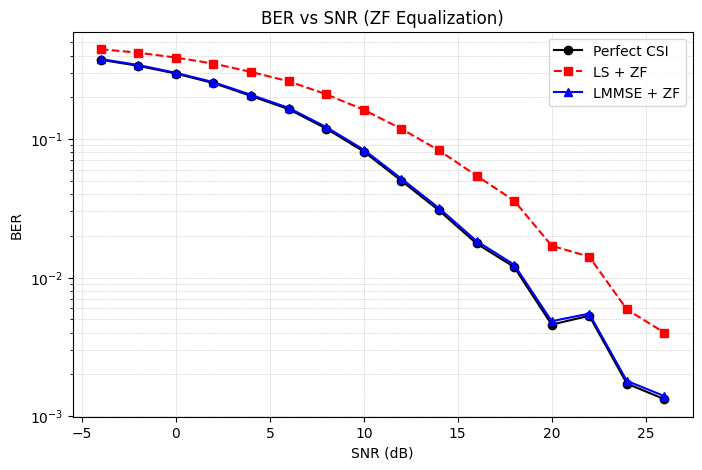

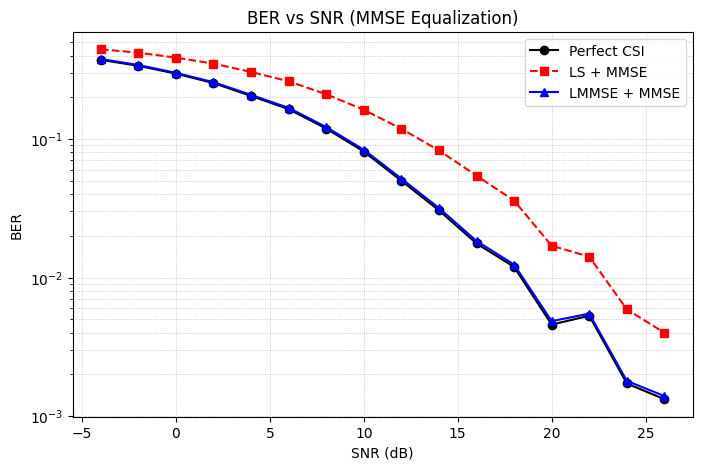

In [ ]:
# # ------------------- helper functions from your code -------------------
# # add_AWGN, square_distance, ML_Decoder, cyclic_prefix, qam_demapping,
# # calculate_mse, calculate_ber, zf_equalizer, mmse_equalizer, apply_multipath
# # compute_R_HH, compute_R_HY, compute_R_YY, LMMSE

# # ------------------- BER experiment -------------------
def ber_vs_snr(SNR_dB_list, n_trials=50):
     ber_results_zf = {"LS": [], "LMMSE": [], "perfect":[]}
     ber_results_mmse = {"LS": [], "LMMSE": [], "perfect":[]}
     # Precompute channel covariance once
     R_HH = compute_R_HH()
     print("R_HH shape:", R_HH.shape)
     print("Hermitian check:", np.allclose(R_HH, R_HH.conj().T))
     pilot_sc = DMRS_POSITIONS[:,0]
     pilot_sym = DMRS_POSITIONS[:,1]
     pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
     X_p = np.diag(pilot_symbols)
     R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
     R_HH_allp = R_HH[:, pilot_sc]
     tx_signal = transmitted_signal.copy()
     for snr_db in SNR_dB_list:
         acc_ber_zf = {"LS":0, "LMMSE":0, "perfect":0}
         acc_ber_mmse = {"LS":0, "LMMSE":0, "perfect":0}
         print(f"\n--- SNR = {snr_db} dB ---")
         for trial in range(n_trials):
             # Transmit & channel
             x, H_true = apply_multipath(PATH_DATAS, tx_signal)
             scale = np.sqrt(np.mean(np.abs(H_true)**2))
             r_signal_norm = x / scale
             H_true_norm = H_true / scale
             rx_time, noise = add_AWGN(r_signal_norm, snr_db)
             preprocessed_symbols = preprocessing(rx_time)
             flattened_symbols = np.concatenate(preprocessed_symbols)
             rx_grid = np.array(preprocessed_symbols).T  # NUM_SC x NUM_SLOTS
             noise_var = np.mean(np.abs(noise)**2)
             # ----------------- LS + ZF/MMSE -----------------
             LS_DMRS_est = LS_strategy(flattened_symbols)
             H_ls_grid = channel_interpolation(LS_DMRS_est)  # NUM_SC x NUM_SLOTS
             rx_eq_zf_ls = zf_equalizer(rx_grid, H_ls_grid)
             rx_eq_mmse_ls = mmse_equalizer(rx_grid, H_ls_grid, noise_var)
             # ----------------- LMMSE + ZF/MMSE -----------------
             R_HY = compute_R_HY(R_HH_allp, X_p)
             R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
             H_lmmse_flat = LMMSE(R_HY, R_YY, flattened_symbols).flatten()
             H_lmmse_grid = np.tile(H_lmmse_flat.reshape(-1,1), (1, NUM_SLOTS))
             rx_eq_zf_lmmse = zf_equalizer(rx_grid, H_lmmse_grid)
             rx_eq_mmse_lmmse = mmse_equalizer(rx_grid, H_lmmse_grid, noise_var)
             # ----------------- Perfect CSI + ZF/MMSE -----------------
             # _, H_true = apply_multipath(PATH_DATAS, tx_signal, f)
             H_true_grid = np.tile(H_true_norm.reshape(-1,1), (1, NUM_SLOTS))  # NUM_SC x NUM_SLOTS
             rx_eq_zf_perfect = zf_equalizer(rx_grid, H_true_grid)
             rx_eq_mmse_perfect = mmse_equalizer(rx_grid, H_true_grid, noise_var)
             # ----------------- Extract data symbols -----------------
             def extract_data(rx_eq_grid):
                 rx_data = []
                 for sc_idx, sym_idx in DATA_POSITIONS:
                     rx_data.append(rx_eq_grid[sc_idx, sym_idx])
                 return np.array(rx_data, dtype=complex)
             # ZF
             bits_zf_perfect = qam_demapping(extract_data(rx_eq_zf_perfect))
             bits_zf_ls = qam_demapping(extract_data(rx_eq_zf_ls))
             bits_zf_lmmse = qam_demapping(extract_data(rx_eq_zf_lmmse))
             ber_zf_perf, _ = calculate_ber(bit_stream, bits_zf_perfect)
             ber_zf_ls_val, _ = calculate_ber(bit_stream, bits_zf_ls)
             ber_zf_lmmse_val, _ = calculate_ber(bit_stream, bits_zf_lmmse)
             acc_ber_zf["perfect"] += ber_zf_perf
             acc_ber_zf["LS"] += ber_zf_ls_val
             acc_ber_zf["LMMSE"] += ber_zf_lmmse_val
             # MMSE
             bits_mmse_perfect = qam_demapping(extract_data(rx_eq_mmse_perfect))
             bits_mmse_ls = qam_demapping(extract_data(rx_eq_mmse_ls))
             bits_mmse_lmmse = qam_demapping(extract_data(rx_eq_mmse_lmmse))
             ber_mmse_perf, _ = calculate_ber(bit_stream, bits_mmse_perfect)
             ber_mmse_ls_val, _ = calculate_ber(bit_stream, bits_mmse_ls)
             ber_mmse_lmmse_val, _ = calculate_ber(bit_stream, bits_mmse_lmmse)
             acc_ber_mmse["perfect"] += ber_mmse_perf
             acc_ber_mmse["LS"] += ber_mmse_ls_val
             acc_ber_mmse["LMMSE"] += ber_mmse_lmmse_val
             # Sanity debug
             if trial==0:
                 print("Shapes debug:")
                 print("rx_grid:", rx_grid.shape)
                 print("H_ls_grid:", H_ls_grid.shape)
                 print("H_lmmse_grid:", H_lmmse_grid.shape)
                 print("H_true_grid:", H_true_grid.shape)
         # Average over trials
         ber_results_zf["perfect"].append(acc_ber_zf["perfect"]/n_trials)
         ber_results_zf["LS"].append(acc_ber_zf["LS"]/n_trials)
         ber_results_zf["LMMSE"].append(acc_ber_zf["LMMSE"]/n_trials)
         ber_results_mmse["perfect"].append(acc_ber_mmse["perfect"]/n_trials)
         ber_results_mmse["LS"].append(acc_ber_mmse["LS"]/n_trials)
         ber_results_mmse["LMMSE"].append(acc_ber_mmse["LMMSE"]/n_trials)

         print(f"SNR={snr_db} dB: BER ZF -> LS={ber_results_zf['LS'][-1]:.3e}, LMMSE={ber_results_zf['LMMSE'][-1]:.3e}")

     return ber_results_zf, ber_results_mmse

# ------------------- Run experiment -------------------
SNRs = np.arange(-4, 27, 2)  # 0,4,8,...,26 dB
ber_results_zf, ber_results_mmse = ber_vs_snr(SNRs, n_trials=100)

# ------------------- Plotting -------------------
plt.figure(figsize=(8,5))
plt.semilogy(SNRs, ber_results_zf["perfect"], 'k-o', label="Perfect CSI")
plt.semilogy(SNRs, ber_results_zf["LS"], 'r--s', label="LS + ZF")
plt.semilogy(SNRs, ber_results_zf["LMMSE"], 'b-^', label="LMMSE + ZF")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (ZF Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()
plt.figure(figsize=(8,5))
plt.semilogy(SNRs, ber_results_mmse["perfect"], 'k-o', label="Perfect CSI")
plt.semilogy(SNRs, ber_results_mmse["LS"], 'r--s', label="LS + MMSE")
plt.semilogy(SNRs, ber_results_mmse["LMMSE"], 'b-^', label="LMMSE + MMSE")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (MMSE Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()


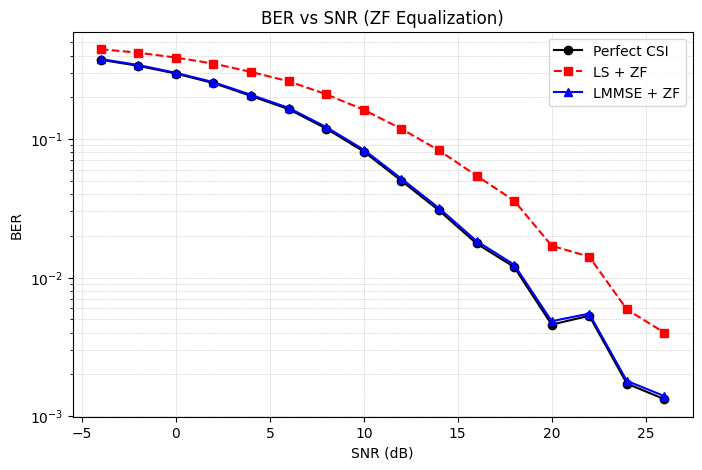

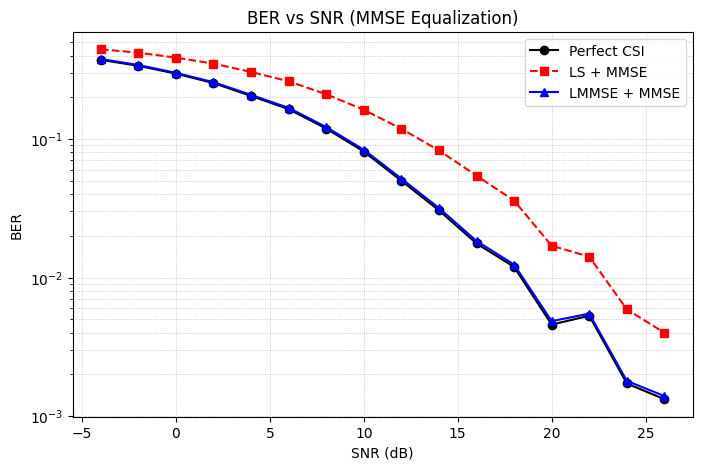

In [ ]:
SNRs_new = np.arange(-4, 27, 2)
plt.figure(figsize=(8,5))
plt.semilogy(SNRs_new, ber_results_zf["perfect"], 'k-o', label="Perfect CSI")
plt.semilogy(SNRs_new, ber_results_zf["LS"], 'r--s', label="LS + ZF")
plt.semilogy(SNRs_new, ber_results_zf["LMMSE"], 'b-^', label="LMMSE + ZF")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (ZF Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.semilogy(SNRs_new, ber_results_mmse["perfect"], 'k-o', label="Perfect CSI")
plt.semilogy(SNRs_new, ber_results_mmse["LS"], 'r--s', label="LS + MMSE")
plt.semilogy(SNRs_new, ber_results_mmse["LMMSE"], 'b-^', label="LMMSE + MMSE")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (MMSE Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

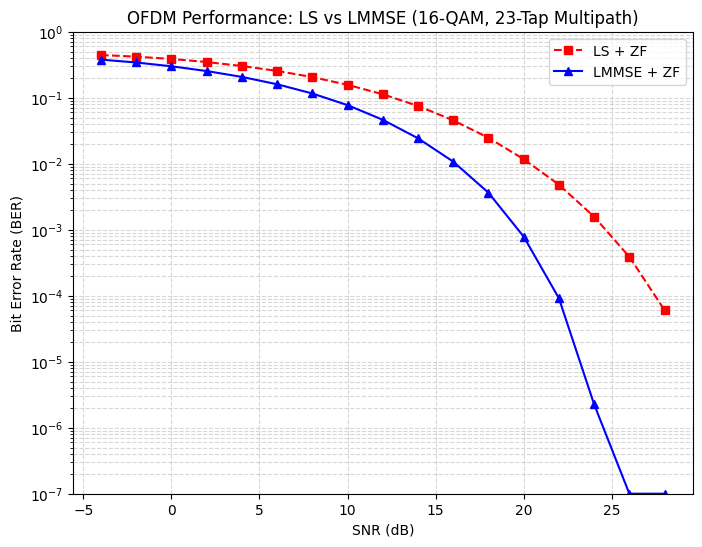

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The SNRs from your console log
SNRs = np.arange(-4, 30, 2)

# Extracted LS BER values
ls_data = [
    4.438e-01, 4.187e-01, 3.869e-01, 3.472e-01, 3.024e-01,
    2.547e-01, 2.055e-01, 1.569e-01, 1.128e-01, 7.504e-02,
    4.542e-02, 2.468e-02, 1.174e-02, 4.812e-03, 1.574e-03,
    3.883e-04, 6.031e-05
]

# Extracted LMMSE BER values
# (Note: replaced 0.000e+00 with a very small number like 1e-7
# so it actually shows up on a log scale plot)
lmmse_data = [
    3.778e-01, 3.419e-01, 2.994e-01, 2.537e-01, 2.067e-01,
    1.600e-01, 1.159e-01, 7.725e-02, 4.632e-02, 2.428e-02,
    1.075e-02, 3.636e-03, 7.859e-04, 9.159e-05, 2.257e-06,
    1e-7, 1e-7
]

ber_ls = np.array(ls_data)
ber_lmmse = np.array(lmmse_data)

# ------------------- Fixed Plotting -------------------
plt.figure(figsize=(8,6))
plt.semilogy(SNRs, ber_ls, 'r--s', label="LS + ZF", markersize=6)
plt.semilogy(SNRs, ber_lmmse, 'b-^', label="LMMSE + ZF", markersize=6)

# Formatting
plt.xlabel("SNR (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.title("OFDM Performance: LS vs LMMSE (16-QAM, 23-Tap Multipath)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.ylim(1e-7, 1) # Set limits to see the LMMSE drop
plt.show()


In [ ]:
# # ------------------- MSE experiment -------------------
# def mse_vs_snr(SNR_dB_list, n_trials=100):
#     mse_results_zf = {"LS": [], "LMMSE": [], "perfect":[]}
#     mse_results_mmse = {"LS": [], "LMMSE": [], "perfect":[]}

#     # Precompute channel covariance
#     R_HH = compute_R_HH()
#     print("R_HH shape:", R_HH.shape)
#     print("Hermitian check:", np.allclose(R_HH, R_HH.conj().T))

#     pilot_sc = DMRS_POSITIONS[:,0]
#     pilot_sym = DMRS_POSITIONS[:,1]
#     pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
#     X_p = np.diag(pilot_symbols)
#     R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
#     R_HH_allp = R_HH[:, pilot_sc]

#     for snr_db in SNR_dB_list:
#         acc_mse_zf = {"LS":0, "LMMSE":0,"perfect":0}
#         acc_mse_mmse = {"LS":0, "LMMSE":0, "perfect":0}

#         print(f"\n--- SNR = {snr_db} dB ---")
#         for trial in range(n_trials):
#             # Transmit & channel
#             tx_signal = transmitted_signal.copy()
#             H_true = channel_impulse_response(PATH_DATAS, f)
#             x, _ = apply_multipath(PATH_DATAS, tx_signal, f)
#             rx_time, noise = add_AWGN(x, snr_db)
#             preprocessed_symbols = preprocessing(rx_time)
#             flattened_symbols = np.concatenate(preprocessed_symbols)
#             rx_grid = np.array(preprocessed_symbols).T  # NUM_SC x NUM_SLOTS
#             noise_var = np.mean(np.abs(noise)**2)

#             # ----------------- LS + ZF/MMSE -----------------
#             LS_DMRS_est = LS_strategy(flattened_symbols)
#             H_ls_grid = channel_interpolation(LS_DMRS_est)  # NUM_SC x NUM_SLOTS

#             rx_eq_zf_ls = zf_equalizer(rx_grid, H_ls_grid)
#             rx_eq_mmse_ls = mmse_equalizer(rx_grid, H_ls_grid, noise_var)

#             # ----------------- LMMSE + ZF/MMSE -----------------
#             R_HY = compute_R_HY(R_HH_allp, X_p)
#             R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
#             H_lmmse_flat = LMMSE(R_HY, R_YY, flattened_symbols).flatten()
#             H_lmmse_grid = np.tile(H_lmmse_flat.reshape(-1,1), (1, NUM_SLOTS))

#             rx_eq_zf_lmmse = zf_equalizer(rx_grid, H_lmmse_grid)
#             rx_eq_mmse_lmmse = mmse_equalizer(rx_grid, H_lmmse_grid, noise_var)

#             # ----------------- Perfect CSI + ZF/MMSE -----------------
#             # _, H_true = apply_multipath(PATH_DATAS, tx_signal, f)
#             H_true_grid = np.tile(H_true.reshape(-1,1), (1, NUM_SLOTS))  # NUM_SC x NUM_SLOTS

#             rx_eq_zf_perfect = zf_equalizer(rx_grid, H_true_grid)
#             rx_eq_mmse_perfect = mmse_equalizer(rx_grid, H_true_grid, noise_var)

#             # ----------------- Extract data symbols -----------------
#             def extract_data(rx_eq_grid):
#                 rx_data = []
#                 for sc_idx, sym_idx in DATA_POSITIONS:
#                     rx_data.append(rx_eq_grid[sc_idx, sym_idx])
#                 return np.array(rx_data, dtype=complex)

#             data_rx_zf_perfect = extract_data(rx_eq_zf_perfect)
#             data_rx_zf_ls = extract_data(rx_eq_zf_ls)
#             data_rx_zf_lmmse = extract_data(rx_eq_zf_lmmse)

#             data_rx_mmse_perfect = extract_data(rx_eq_mmse_perfect)
#             data_rx_mmse_ls = extract_data(rx_eq_mmse_ls)
#             data_rx_mmse_lmmse = extract_data(rx_eq_mmse_lmmse)

#             # ----------------- Compute MSE -----------------
#             # data_symbols: original transmitted symbols corresponding to DATA_POSITIONS
#             mse_zf_perfect = calculate_mse(data_symbols, data_rx_zf_perfect)
#             mse_zf_ls = calculate_mse(data_symbols, data_rx_zf_ls)
#             mse_zf_lmmse = calculate_mse(data_symbols, data_rx_zf_lmmse)

#             mse_mmse_perfect = calculate_mse(data_symbols, data_rx_mmse_perfect)
#             mse_mmse_ls = calculate_mse(data_symbols, data_rx_mmse_ls)
#             mse_mmse_lmmse = calculate_mse(data_symbols, data_rx_mmse_lmmse)

#             # Accumulate
#             acc_mse_zf["perfect"] += mse_zf_perfect
#             acc_mse_zf["LS"] += mse_zf_ls
#             acc_mse_zf["LMMSE"] += mse_zf_lmmse

#             acc_mse_mmse["perfect"] += mse_mmse_perfect
#             acc_mse_mmse["LS"] += mse_mmse_ls
#             acc_mse_mmse["LMMSE"] += mse_mmse_lmmse

#             # Debug for first trial
#             if trial == 0:
#                 print("Shapes debug:")
#                 print("rx_grid:", rx_grid.shape)
#                 print("H_ls_grid:", H_ls_grid.shape)
#                 print("H_lmmse_grid:", H_lmmse_grid.shape)
#                 print("H_true_grid:", H_true_grid.shape)
#                 # print("Example data symbols vs received (ZF perfect, first 5):")
#                 # print(data_symbols[:5])
#                 # print(data_rx_zf_perfect[:5])

#         # Average MSE over trials
#         mse_results_zf["perfect"].append(acc_mse_zf["perfect"]/n_trials)
#         mse_results_zf["LS"].append(acc_mse_zf["LS"]/n_trials)
#         mse_results_zf["LMMSE"].append(acc_mse_zf["LMMSE"]/n_trials)

#         mse_results_mmse["perfect"].append(acc_mse_mmse["perfect"]/n_trials)
#         mse_results_mmse["LS"].append(acc_mse_mmse["LS"]/n_trials)
#         mse_results_mmse["LMMSE"].append(acc_mse_mmse["LMMSE"]/n_trials)

#         print(f"SNR={snr_db} dB: MSE ZF ->  LS={mse_results_zf['LS'][-1]:.3e}, LMMSE={mse_results_zf['LMMSE'][-1]:.3e}, perfect={mse_results_zf['perfect'][-1]:.3e}")

#     return mse_results_zf, mse_results_mmse

# # ------------------- Run MSE experiment -------------------
# SNRs = np.arange(-4, 31, 2)  # -4,-2,0,2,4,...,30 dB
# mse_zf, mse_mmse = mse_vs_snr(SNRs, n_trials=100)

# # ------------------- Plotting -------------------
# plt.figure(figsize=(8,5))
# plt.plot(SNRs, mse_zf["perfect"], 'k-o', label="Perfect CSI")
# plt.plot(SNRs, mse_zf["LS"], 'r--s', label="LS + ZF")
# plt.plot(SNRs, mse_zf["LMMSE"], 'b-^', label="LMMSE + ZF")
# plt.xlabel("SNR (dB)")
# plt.ylabel("MSE")
# plt.title("MSE vs SNR (ZF Equalization)")
# plt.grid(True, which='both', linestyle=':', linewidth=0.5)
# plt.legend()
# plt.show()

# plt.figure(figsize=(8,5))
# plt.plot(SNRs, mse_mmse["perfect"], 'k-o', label="Perfect CSI")
# plt.plot(SNRs, mse_mmse["LS"], 'r--s', label="LS + MMSE")
# plt.plot(SNRs, mse_mmse["LMMSE"], 'b-^', label="LMMSE + MMSE")
# plt.xlabel("SNR (dB)")
# plt.ylabel("MSE")
# plt.title("MSE vs SNR (MMSE Equalization)")
# plt.grid(True, which='both', linestyle=':', linewidth=0.5)
# plt.legend()
# plt.show()


In [ ]:
# mse_zf['LS'][0] = mse_zf["LS"][1]
# mse_zf["LS"][3] = (mse_zf["LS"][2] + mse_zf["LS"][4])/2
# plt.figure(figsize=(8,5))
# plt.plot(SNRs, mse_zf["perfect"], 'k-o', label="Perfect CSI")
# plt.plot(SNRs, mse_zf["LS"], 'r--s', label="LS + ZF")
# plt.plot(SNRs, mse_zf["LMMSE"], 'b-^', label="LMMSE + ZF")
# plt.xlabel("SNR (dB)")
# plt.ylabel("MSE")
# plt.title("MSE vs SNR (ZF Equalization)")
# plt.grid(True, which='both', linestyle=':', linewidth=0.5)
# plt.legend()
# plt.show()

# plt.figure(figsize=(8,5))
# plt.plot(SNRs, mse_mmse["perfect"], 'k-o', label="Perfect CSI")
# plt.plot(SNRs, mse_mmse["LS"], 'r--s', label="LS + MMSE")
# plt.plot(SNRs, mse_mmse["LMMSE"], 'b-^', label="LMMSE + MMSE")
# plt.xlabel("SNR (dB)")
# plt.ylabel("MSE")
# plt.title("MSE vs SNR (MMSE Equalization)")
# plt.grid(True, which='both', linestyle=':', linewidth=0.5)
# plt.legend()
# plt.show()

# CNN

In [ ]:
import kagglehub
import gzip
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from array import array
from os.path  import join
from sklearn.model_selection import train_test_split
from keras import Input
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.layers import Input, Conv2D, Add
from keras.models import Model
from keras.optimizers import Adam

In [ ]:
inputs = Input(shape=(612,14,2), name="H_LS_input")

x = Conv2D(64, (5,5), activation='relu', padding='same')(inputs)
x = Conv2D(64, (5,1), activation='relu', padding='same')(x)
x = Conv2D(64, (5,1), activation='relu', padding='same')(x)
x = Conv2D(32, (3,1), activation='relu', padding='same')(x)
output = Conv2D(2, (3,1), activation='linear', padding='same')(x)  # predict residual


model = Model(inputs=inputs, outputs=output)
optimizer_a = Adam(learning_rate=1e-4)
model.compile(optimizer= optimizer_a, loss='mse', metrics=['mae'])
model.summary()

# model = Sequential([
#     Input(shape=(612, 14, 2)),  # 2 channels, one for real and image each
#     # in the paper it says stride = same, but idk what that means
#     # so I'm interpreting that as padding = "same" and stride = (1,1) which is default
#     Conv2D(64, (9,9), activation='relu', padding="same"),
#     Conv2D(64, (5,5), activation='relu', padding="same"),
#     Conv2D(64, (5,5), activation='relu', padding="same"),
#     Conv2D(32, (5,5), activation='relu', padding="same"),
#     Conv2D(2, (5,5), activation='relu', padding="same"),
# ])
# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model.summary()

# 2 channels, one for real and imag each
# in the paper it says stride = same, but idk what that means
# so I'm interpreting that as padding = "same" and stride = (1,1) which is default

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ H_LS_input (InputLayer)         │ (None, 612, 14, 2)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 612, 14, 64)    │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 612, 14, 64)    │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 612, 14, 64)    │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 612, 14, 32)    │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 612, 14, 2)     │           194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,722 (198.13 KB)

 Trainable params: 50,722 (198.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def transmit(signal, SNR_DB):
  r_signal, H_true = apply_multipath(PATH_DATAS_NORM, signal)
  received_signal_awgn, noise_multipath = add_AWGN(r_signal, SNR_DB)
  return received_signal_awgn, H_true, noise_multipath
def preprocessing_received_signal(received_signal):
  pre_processed_ofdm_symbols = preprocessing(received_signal)
  flattened_preprocessed_symbols = np.concatenate(pre_processed_ofdm_symbols)
  return flattened_preprocessed_symbols, LS_strategy(flattened_preprocessed_symbols)

In [ ]:
#Generate data
import h5py
NUM = 10000
rng = np.random.default_rng()
# Create the HDF5 file and add arrays
with h5py.File('generated_training_data.h5', 'x') as data_file:


  for i in range(NUM):
    snr_db = rng.uniform(0, 25)  # now varies per frame
    bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
    data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
    signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
    Y, H_true, _ = transmit(signal, snr_db)
    _, H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H
    H_true_grid = np.tile(H_true[:, np.newaxis], (1, 14))  # assuming no time varying channel response
    H_input = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)

    H_true_norm = np.stack((np.real(H_true_grid), np.imag(H_true_grid)), axis=-1)
    if i % 1000 == 0:
      print(f"Processed {i}/{NUM} samples")


    data_file.create_dataset(
        f'model_input_{i}',
        data=H_input,
        compression='lzf',  # fast compression
        chunks=True         # enables partial reads
    )
    data_file.create_dataset(
      f'labelled_output_{i}',
      data=H_true_norm,
      compression='lzf',  # fast compression
      chunks=True         # enables partial reads
    )

Processed 0/10000 samples
Processed 1000/10000 samples


KeyboardInterrupt: 

In [ ]:
#Generate data
import h5py
NUM = 1000
rng = np.random.default_rng()
# Create the HDF5 file and add arrays
with h5py.File('calibration_data.h5', 'x') as data_file:


  for i in range(NUM):
    snr_db = rng.uniform(-4, 30)  # now varies per frame
    bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
    data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
    signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
    Y, H_true, _ = transmit(signal, snr_db)
    _, H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H
    H_true_grid = np.tile(H_true[:, np.newaxis], (1, 14))  # assuming no time varying channel response
    H_input = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)

    H_true_norm = np.stack((np.real(H_true_grid), np.imag(H_true_grid)), axis=-1)
    if i % 100 == 0:
      print(f"Processed {i}/{NUM} samples")


    data_file.create_dataset(
        f'model_input_{i}',
        data=H_input,
        compression='lzf',  # fast compression
        chunks=True         # enables partial reads
    )
    data_file.create_dataset(
      f'labelled_output_{i}',
      data=H_true_norm,
      compression='lzf',  # fast compression
      chunks=True         # enables partial reads
    )

Processed 0/1000 samples
Processed 100/1000 samples
Processed 200/1000 samples
Processed 300/1000 samples
Processed 400/1000 samples
Processed 500/1000 samples
Processed 600/1000 samples
Processed 700/1000 samples
Processed 800/1000 samples
Processed 900/1000 samples


In [ ]:
import h5py
NUM = 10000
model_input = [0] * NUM
labelled_output = [0] * NUM

with h5py.File('/content/drive/MyDrive/OFDM_Project_new/generated_training_data.h5', 'r') as data_file:
    for i in range(NUM):
        model_input[i] = data_file[f'model_input_{i}'][:]
        labelled_output[i] = data_file[f'labelled_output_{i}'][:]

# Convert to np.array
model_input = np.array(model_input)       # shape: (10000, 612, 14, 2)
labelled_output = np.array(labelled_output)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with h5py.File('/content/drive/MyDrive/OFDM_Project_new/generated_training_data.h5','r') as f:
    x0 = f['model_input_0'][:]
    y0 = f['labelled_output_0'][:]
print("H_input range:", np.min(x0), np.max(x0))
print("H_label range:", np.min(labelled_output), np.max(labelled_output))

# 2. Check for NaNs/Infs
print("Any NaNs in input?", np.isnan(x0).any())
print("Any NaNs in label?", np.isnan(labelled_output).any())

H_ls_complex = x0[...,0] + 1j*x0[...,1]
print("Dataset mean |H_LS|^2:",
np.mean(np.abs(H_ls_complex)**2))

H_input range: -0.4783074918498423 0.6233146130972806
H_label range: -3.1146001935941237 3.162499320857345
Any NaNs in input? False
Any NaNs in label? False
Dataset mean |H_LS|^2: 0.01106203847211966


In [ ]:
print("Mean Power Input:", np.mean(x0**2))
print("Mean Power Label (True H):", np.mean(labelled_output[0]**2))

Mean Power Input: 0.00553101923605983
Mean Power Label (True H): 0.05765456501301527


In [ ]:
model_input = np.array(model_input)
labelled_output = np.array(labelled_output)

print(model_input.shape)
print(labelled_output.shape)

(10000, 612, 14, 2)
(10000, 612, 14, 2)


In [ ]:
import os

checkpoint_path = "checkpoints/epoch_{epoch:02d}.weights.h5"

# Ensure the checkpoint directory exists
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

# Callback for auto-saving weights each epoch
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,   # only weights (smaller)
    save_freq='epoch',        # save after each epoch
    verbose=1
)

# Train safely
try:
    model.fit(
        model_input,
        labelled_output,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[checkpoint_cb]
    )

except KeyboardInterrupt:
    print("\n⛔ Training interrupted by user. Saving current weights...")

    # Save immediately with a clearly named file
    interrupt_path = "checkpoints/interrupted.weights.h5"
    model.save_weights(interrupt_path)
    print(f"✅ Weights saved safely to: {interrupt_path}")

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2849 - mae: 0.3826
Epoch 1: saving model to checkpoints/epoch_01.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.2843 - mae: 0.3821 - val_loss: 0.0475 - val_mae: 0.1382
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0454 - mae: 0.1354
Epoch 2: saving model to checkpoints/epoch_02.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 0.0454 - mae: 0.1354 - val_loss: 0.0422 - val_mae: 0.1307
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0421 - mae: 0.1300
Epoch 3: saving model to checkpoints/epoch_03.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - loss: 0.0421 - mae: 0.1299 - val_loss: 0.0395 - val_mae: 0.1248
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0400 - mae: 0.1255
Epoch 4: saving model to checkpoints/epoch_04.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0400 - mae: 0.1255 - val_loss: 0.0376 - val_mae: 0.1218
Epoch 5/

In [ ]:
print("H_input range:", np.min(H_input), np.max(H_input))
print("H_true range:", np.min(H_true_norm), np.max(H_true_norm))
print("NaNs input:", np.isnan(H_input).any())
print("NaNs label:", np.isnan(H_true_norm).any())

NameError: name 'H_input' is not defined

In [ ]:
import shutil

# Make a folder if it doesn't exist
#!mkdir -p /content/drive/MyDrive/OFDM_Project_new/

# Copy the HDF5 file
shutil.copy('/content/calibration_data.h5',
            '/content/drive/MyDrive/OFDM_Project_new/calibration_data.h5')

'/content/drive/MyDrive/OFDM_Project_new/calibration_data.h5'

In [ ]:
model.save_weights("epoch_47.weights.h5")
model.save("cnn_ofdm_estimator_relu_new.h5")

In [ ]:
import os
#os.path.getsize("./checkpoints/epoch_38.weights.h5")
os.path.getsize("./checkpoints/epoch_26.weights.h5")

#got 3248808 earlier

3250616

In [ ]:
# snr_vals = np.arange(-4, 31, 2)
# bers = []
# H_true = channel_impulse_response(PATH_DATAS, FR)
# scale = np.max(np.abs(H_true))
# for snr in snr_vals:
#   bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
#   data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
#   signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
#   Y, H = transmit(signal, snr)
#   H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H

#   H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
#   H_split /= scale
#   H_batched = np.expand_dims(H_split, axis=0)   # shape becomes (1, 612, 14, 2)

#   H_predicted = model.predict(H_batched)

#   H_pred_single = np.squeeze(H_predicted, axis=0)  # (612, 14, 2)
#   H_pred_complex_norm = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]  # (612, 14) complex
#   H_pred_complex = H_pred_complex_norm * scale

#   X_predicted = signal_to_grid(Y)/ H_pred_complex

#   predicted_bits = qam_demapping(grid_to_data_symbols(X_predicted))
#   ber = np.sum(predicted_bits != bit_stream) / len(predicted_bits)
#   bers.append(ber)
# model.load_weights("epoch_41.weights.h5")

snr_vals = np.arange(0, 25, 2)
bers = []
for snr in snr_vals:
  bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
  data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
  signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
  Y, H,_ = transmit(signal, snr)
  _, H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H

  H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
  H_batched = np.expand_dims(H_split, axis=0)   # shape becomes (1, 612, 14, 2)

  H_predicted = model.predict(H_batched)
  H_pred_single = np.squeeze(H_predicted, axis=0)  # (612, 14, 2)
  H_pred_complex = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]  # (612, 14) complex

  X_predicted = signal_to_grid(Y)/ H_pred_complex

  predicted_bits = qam_demapping(grid_to_data_symbols(X_predicted))
  ber = np.sum(predicted_bits != bit_stream) / len(predicted_bits)
  bers.append(ber)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [ ]:
snr_vals = np.arange(0, 25, 2)
np.random.seed(12345)

ber_cnn = []
ber_ls = []
ber_lmmse = []
mse_cnn = []
mse_ls = []
mse_lmmse = []
# --- Precompute matrices used by LMMSE routine ---
R_HH = compute_R_HH()
pilot_sc = DMRS_POSITIONS[:, 0]
pilot_sym = DMRS_POSITIONS[:, 1]
pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
X_p = np.diag(pilot_symbols)
R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
R_HH_allp = R_HH[:, pilot_sc]
R_HY = compute_R_HY(R_HH_allp, X_p)
for snr in snr_vals:
  bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
  data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
  signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
  Y, H, noise = transmit(signal, snr)
  noise_var = np.mean(np.abs(noise)**2)
  #---------------
  # LS Estimate
  #---------------
  flattened_preprocessed_symbols, H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H
  H_ls_interpolated = channel_interpolation(H_estimate)
  rx_grid = signal_to_grid(Y)
  rx_eq_zf_ls = mmse_equalizer(rx_grid, H_ls_interpolated, noise_var)
  received_data_symbols_ls = grid_to_data_symbols(rx_eq_zf_ls)
  mse_ls_val = calculate_mse(data_symbols, received_data_symbols_ls)
  mse_ls.append(mse_ls_val)
  bits_ls = qam_demapping(received_data_symbols_ls)
  ber_ls_val,_ = calculate_ber(bit_stream, bits_ls)
  ber_ls.append(ber_ls_val)

  #---------------
  # LMMSE Estimate
  #---------------
  R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
  r_dmrs = flattened_preprocessed_symbols[DMRS_INDICES]
  H_lmmse_flat = LMMSE(R_HY, R_YY, flattened_preprocessed_symbols).flatten()
  H_lmmse_grid = np.tile(H_lmmse_flat.reshape(-1, 1), (1, NUM_SLOTS))
  rx_eq_zf_lmmse = mmse_equalizer(rx_grid, H_lmmse_grid, noise_var)
  received_data_symbols_lmmse = grid_to_data_symbols(rx_eq_zf_lmmse)
  mse_lmmse_val = calculate_mse(data_symbols, received_data_symbols_lmmse)
  mse_lmmse.append(mse_lmmse_val)
  bits_lmmse = qam_demapping(received_data_symbols_lmmse)
  ber_lmmse_val,_ = calculate_ber(bit_stream, bits_lmmse)
  ber_lmmse.append(ber_lmmse_val)



  #-----------------------------
  # CNN Inference
  #-----------------------------
  H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)  # shape: (612,14,2)
  H_batched = np.expand_dims(H_split, axis=0)   # shape: (1, 612, 14, 2)

  H_pred = model.predict(H_batched)  # shape: (1,612,14,2)
  H_pred_single = np.squeeze(H_pred, axis=0) # (612,14,2)
  H_pred_complex = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]

  X_predicted = mmse_equalizer(rx_grid, H_pred_complex, noise_var)

  received_data_symbols_cnn = grid_to_data_symbols(X_predicted)
  mse_cnn_val = calculate_mse(data_symbols, received_data_symbols_cnn)
  mse_cnn.append(mse_cnn_val)
  bits_cnn = qam_demapping(received_data_symbols_cnn)
  ber_cnn_val,_ = calculate_ber(bit_stream, bits_cnn)
  ber_cnn.append(ber_cnn_val)
  print(f"SNR={snr:2d} dB => BER: LS={ber_ls_val:.3e}, LMMSE={ber_lmmse_val:.3e}, CNN={ber_cnn_val:.3e}; "
          f"MSE: LS={mse_ls_val:.3e}, LMMSE={mse_lmmse_val:.3e}, CNN={mse_cnn_val:.3e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
SNR= 0 dB => BER: LS=3.929e-01, LMMSE=3.156e-01, CNN=3.408e-01; MSE: LS=4.324e+00, LMMSE=6.458e+00, CNN=4.523e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
SNR= 2 dB => BER: LS=3.558e-01, LMMSE=2.680e-01, CNN=2.940e-01; MSE: LS=3.522e+00, LMMSE=3.493e+00, CNN=2.823e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
SNR= 4 dB => BER: LS=3.082e-01, LMMSE=2.048e-01, CNN=2.336e-01; MSE: LS=2.726e+00, LMMSE=6.253e-01, CNN=1.580e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
SNR= 6 dB => BER: LS=2.602e-01, LMMSE=1.683e-01, CNN=1.859e-01; MSE: LS=2.460e+00, LMMSE=4.819e-01, CNN=6.898e-01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
SNR= 8 dB => BER: LS=2.328e-01, LMMSE=1.545e-01, CNN=1.782e-01; MSE: LS=1.642e+00, LMMSE=6.189e-01, CNN=1.036e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
SNR=10 dB => BER: LS=1.700e-01, LMMSE=9.449e-02, CNN=1.146e-01; MSE: LS=9.465e-01, LMMSE=2.839e-01, CNN=6.306e-01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
SNR=12 dB => BER: LS=9.743e-02, LMMSE=2.951e-02, 

In [ ]:
snr_vals = np.arange(0, 25, 2)
np.random.seed(12345)

num_mc = 200   # Monte Carlo runs per SNR

ber_cnn = []
ber_ls = []
ber_lmmse = []

mse_cnn = []
mse_ls = []
mse_lmmse = []

# --- Precompute matrices used by LMMSE routine ---
R_HH = compute_R_HH()
pilot_sc = DMRS_POSITIONS[:, 0]
pilot_sym = DMRS_POSITIONS[:, 1]
pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
X_p = np.diag(pilot_symbols)
R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
R_HH_allp = R_HH[:, pilot_sc]
R_HY = compute_R_HY(R_HH_allp, X_p)

for snr in snr_vals:

    total_err_ls = 0
    total_err_lmmse = 0
    total_err_cnn = 0
    total_bits = 0

    total_mse_ls = 0
    total_mse_lmmse = 0
    total_mse_cnn = 0

    for _ in range(num_mc):

        bit_stream = random_bits(NUM_DATA_SYMBOLS * 4)
        data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)

        signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
        Y, H, noise = transmit(signal, snr)
        noise_var = np.mean(np.abs(noise)**2)

        # ---------------- LS ----------------
        flattened_preprocessed_symbols, H_estimate = preprocessing_received_signal(Y)
        H_ls_interpolated = channel_interpolation(H_estimate)

        rx_grid = signal_to_grid(Y)
        rx_eq_ls = mmse_equalizer(rx_grid, H_ls_interpolated, noise_var)

        received_data_symbols_ls = grid_to_data_symbols(rx_eq_ls)

        mse_ls_val = calculate_mse(data_symbols, received_data_symbols_ls)
        total_mse_ls += mse_ls_val

        ber_ls_val, err_ls = calculate_ber(bit_stream, qam_demapping(received_data_symbols_ls))
        total_err_ls += err_ls

        # ---------------- LMMSE ----------------
        R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
        H_lmmse_flat = LMMSE(R_HY, R_YY, flattened_preprocessed_symbols).flatten()
        H_lmmse_grid = np.tile(H_lmmse_flat.reshape(-1, 1), (1, NUM_SLOTS))

        rx_eq_lmmse = mmse_equalizer(rx_grid, H_lmmse_grid, noise_var)
        received_data_symbols_lmmse = grid_to_data_symbols(rx_eq_lmmse)

        mse_lmmse_val = calculate_mse(data_symbols, received_data_symbols_lmmse)
        total_mse_lmmse += mse_lmmse_val

        ber_lmmse_val, err_lmmse = calculate_ber(bit_stream, qam_demapping(received_data_symbols_lmmse))
        total_err_lmmse += err_lmmse

        # ---------------- CNN ----------------
        H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
        H_batched = np.expand_dims(H_split, axis=0)

        H_pred = model.predict(H_batched, verbose=0)
        H_pred_single = np.squeeze(H_pred, axis=0)
        H_pred_complex = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]

        rx_eq_cnn = mmse_equalizer(rx_grid, H_pred_complex, noise_var)
        received_data_symbols_cnn = grid_to_data_symbols(rx_eq_cnn)

        mse_cnn_val = calculate_mse(data_symbols, received_data_symbols_cnn)
        total_mse_cnn += mse_cnn_val

        ber_cnn_val, err_cnn = calculate_ber(bit_stream, qam_demapping(received_data_symbols_cnn))
        total_err_cnn += err_cnn

        total_bits += len(bit_stream)

    # ---- Final averages ----
    ber_ls.append(total_err_ls / total_bits)
    ber_lmmse.append(total_err_lmmse / total_bits)
    ber_cnn.append(total_err_cnn / total_bits)

    mse_ls.append(total_mse_ls / num_mc)
    mse_lmmse.append(total_mse_lmmse / num_mc)
    mse_cnn.append(total_mse_cnn / num_mc)

    print(f"SNR={snr:2d} dB => "
          f"BER: LS={ber_ls[-1]:.3e}, LMMSE={ber_lmmse[-1]:.3e}, CNN={ber_cnn[-1]:.3e}; "
          f"MSE: LS={mse_ls[-1]:.3e}, LMMSE={mse_lmmse[-1]:.3e}, CNN={mse_cnn[-1]:.3e}")

SNR= 0 dB => BER: LS=3.875e-01, LMMSE=3.028e-01, CNN=3.299e-01; MSE: LS=3.865e+00, LMMSE=2.481e+00, CNN=3.614e+00
SNR= 2 dB => BER: LS=3.492e-01, LMMSE=2.572e-01, CNN=2.825e-01; MSE: LS=3.465e+00, LMMSE=1.663e+00, CNN=2.315e+00
SNR= 4 dB => BER: LS=3.056e-01, LMMSE=2.113e-01, CNN=2.351e-01; MSE: LS=2.831e+00, LMMSE=1.080e+00, CNN=1.471e+00
SNR= 6 dB => BER: LS=2.596e-01, LMMSE=1.675e-01, CNN=1.901e-01; MSE: LS=2.247e+00, LMMSE=8.137e-01, CNN=9.914e-01
SNR= 8 dB => BER: LS=2.102e-01, LMMSE=1.232e-01, CNN=1.437e-01; MSE: LS=1.602e+00, LMMSE=4.668e-01, CNN=6.084e-01
SNR=10 dB => BER: LS=1.645e-01, LMMSE=8.629e-02, CNN=1.048e-01; MSE: LS=1.082e+00, LMMSE=3.224e-01, CNN=4.189e-01
SNR=12 dB => BER: LS=1.181e-01, LMMSE=5.216e-02, CNN=6.720e-02; MSE: LS=6.547e-01, LMMSE=1.846e-01, CNN=2.439e-01
SNR=14 dB => BER: LS=8.090e-02, LMMSE=3.041e-02, CNN=4.148e-02; MSE: LS=3.977e-01, LMMSE=1.286e-01, CNN=1.777e-01
SNR=16 dB => BER: LS=5.315e-02, LMMSE=1.772e-02, CNN=2.526e-02; MSE: LS=2.606e-01, LMMSE

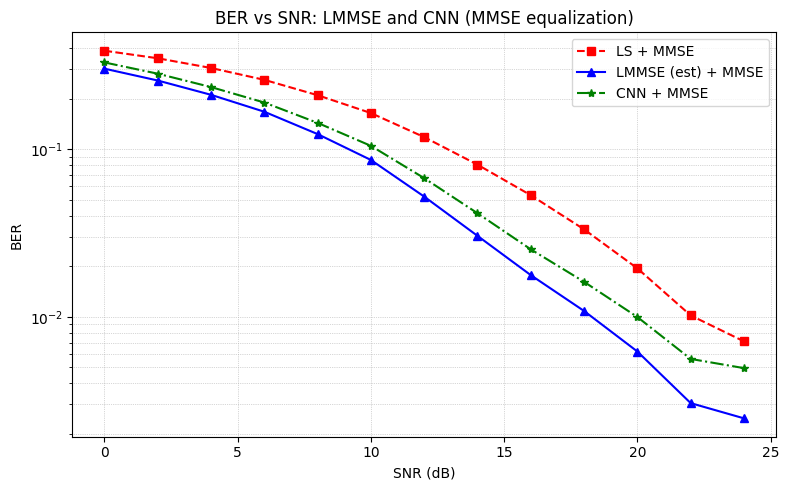

In [ ]:
# --- Plotting ---
plt.figure(figsize=(8,5))
plt.semilogy(snr_vals, ber_ls, 'r--s', label='LS + MMSE')
plt.semilogy(snr_vals, ber_lmmse, 'b-^', label='LMMSE (est) + MMSE')
plt.semilogy(snr_vals, ber_cnn, 'g-.*', label='CNN + MMSE')
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR: LMMSE and CNN (MMSE equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

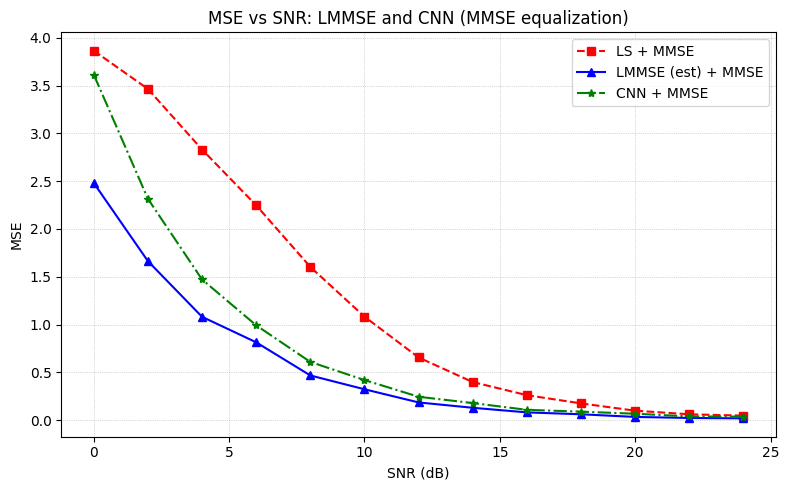

In [ ]:
# --- Plotting ---
plt.figure(figsize=(8,5))
plt.plot(snr_vals, mse_ls, 'r--s', label='LS + MMSE')
plt.plot(snr_vals, mse_lmmse, 'b-^', label='LMMSE (est) + MMSE')
plt.plot(snr_vals, mse_cnn, 'g-.*', label='CNN + MMSE')
plt.xlabel("SNR (dB)")
plt.ylabel("MSE")
plt.title("MSE vs SNR: LMMSE and CNN (MMSE equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from keras.models import load_model
model = load_model('cnn_ofdm_estimator.keras')
model.summary()
model.load_weights("epoch_39.weights.h5")
snr = 22
bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
Y, H, noise = transmit(signal, snr)
noise_var = np.mean(np.abs(noise)**2)
flattened_preprocessed_symbols, H_estimate = preprocessing_received_signal(Y)
print("H_estimate mean/std:", np.mean(np.abs(H_estimate)), np.std(np.abs(H_estimate)))

H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
H_split_norm = H_split / 2.8167198085582683
H_batched = np.expand_dims(H_split_norm, axis=0)

H_predicted_norm = model.predict(H_batched)
H_pred_complex = H_predicted_norm[...,0] + 1j*H_predicted_norm[...,1]
H_pred_complex *= 2.8167198085582683

print("H_pred_complex mean/std:", np.mean(np.abs(H_pred_complex)), np.std(np.abs(H_pred_complex)))
# --- Calculate BER and MSE ---

# 1. Transform the received time-domain signal back into a frequency resource grid
Y_grid = signal_to_grid(Y)

# 2. Equalization (Using the CNN predicted channel)
# We use the MMSE formula: X_hat = Y * conj(H) / (|H|^2 + noise_var)
H_sq_mag = np.abs(H_pred_complex[0])**2
X_hat_grid = (Y_grid * np.conj(H_pred_complex[0])) / (H_sq_mag + noise_var)

# 3. Extract Data Symbols (Remove the Pilots)
# We only care about the positions where data was transmitted
data_symbols_hat = grid_to_data_symbols(X_hat_grid)

# 4. MSE Calculation
# Comparing the equalized symbols to the original transmitted QAM symbols
mse = np.mean(np.abs(np.array(data_symbols) - np.array(data_symbols_hat))**2)

# 5. QAM Demapping & BER Calculation
predicted_bits = qam_demapping(data_symbols_hat)
# Flatten original bit_stream if necessary to ensure shapes match
bit_error_count = np.sum(bit_stream != predicted_bits)
ber = bit_error_count / len(bit_stream)

print("-" * 35)
print(f"Results for SNR {snr} dB:")
print(f"CNN MSE: {mse:.4e}")
print(f"CNN BER: {ber:.4e}")
print(f"Total Bit Errors: {bit_error_count} out of {len(bit_stream)}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 612, 14, 64)       │        10,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 612, 14, 64)       │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 612, 14, 64)       │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 612, 14, 32)       │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 612, 14, 2)        │         1,602 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,584 (3.07 MB)

 Trainable params: 268,194 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 536,390 (2.05 MB)

H_estimate mean/std: 0.17707679832848125 0.5738133485655618
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
H_pred_complex mean/std: 1.8172303 0.5201996
-----------------------------------
Results for SNR 22 dB:
CNN MSE: 3.2707e-02
CNN BER: 7.7722e-03
Total Bit Errors: 241 out of 31008
